# Credit Card Fraud Detection - Exploratory Data Analysis

Credit card fraud represents a major challenge for financial institutions and online payment systems. As digital transactions continue to grow, detecting fraudulent activities quickly and accurately becomes critical to protect both customers and financial organizations.

The objective of this project is to analyze and build machine learning models capable of identifying fraudulent credit card transactions. Before developing predictive models, it is essential to perform an Exploratory Data Analysis (EDA) in order to understand the structure of the dataset, identify potential data quality issues, and explore patterns that may help distinguish fraudulent transactions from legitimate ones.

The dataset used in this project contains credit card transactions made by European cardholders in September 2013. It includes 284,807 transactions, among which 492 are fraudulent. Due to confidentiality constraints, most features have been transformed using Principal Component Analysis (PCA). As a result, the dataset contains 28 anonymized numerical features (V1–V28), in addition to two original variables:

- Time: the number of seconds elapsed between the transaction and the first transaction in the dataset
- Amount: the transaction amount
- Class: the target variable indicating whether the transaction is fraudulent (1) or legitimate (0)

The goal of this exploratory analysis is therefore to:

- Understand the dataset structure and feature distributions
- Identify potential data quality issues such as missing values or duplicate records
- Analyze the distribution of fraudulent and non-fraudulent transactions
- Explore correlations between features and the target variable
- Prepare the dataset for subsequent machine learning modeling

This analysis will provide key insights into the data and guide the design of robust fraud detection models in later stages of the project.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot parameters
# Style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

# Font sizes
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 22
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

## Load dataset

In [2]:
# Load raw dataset
base = pd.read_csv("../data/raw/creditcard.csv")
# Display first five rows
base.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset overview

In [3]:
print("Dataset shape:", base.shape)

base.info()

Dataset shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float6

The dataset contains:

- 284,807 transactions
- 31 variables
    - 28 anonymized PCA features (V1 - V28)
    - Time and Amount features
    - Target variable: Class
- there's no missing values

The types of the variables are corrects.

In [4]:
# Save original copy 
base_ini = base.copy()

## Duplicate analysis

In [5]:
duplicates = base.duplicated().sum()
print(f"Number of duplicated rows: {duplicates}")

Number of duplicated rows: 1081


The dataset contains 1,081 duplicates transactions.

Since they contain exactly the same information, we remove them to avoid bias in model training.

In [6]:
# Remove duplicates
base = base.drop_duplicates()
print("Dataset shape after removing duplicates:", base.shape)

Dataset shape after removing duplicates: (283726, 31)


After removing duplicates, the new dataset contains:
- 283 726 transactions 
- 31 variables

In [7]:
# Checking
base.duplicated().sum()

np.int64(0)

No more duplicates.

## Missing value analysis

In [8]:
missing_values = base.isnull().sum()
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "No missing values")

No missing values


The dataset contains no missing values.

## Target variable analysis

In [9]:
# Target variable distribution
base["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

The dataset contains:

- 283 253 legitimate transactions
- 473 fraud transactions

In [10]:
# Fraud ratio

# Compute the fraud ratio to understand class imbalance
fraud_ratio = base["Class"].mean()
print(f"Fraud ratio: {fraud_ratio:.4f}")
print(f"Fraud percentage: {fraud_ratio * 100:.3f}%")

Fraud ratio: 0.0017
Fraud percentage: 0.167%


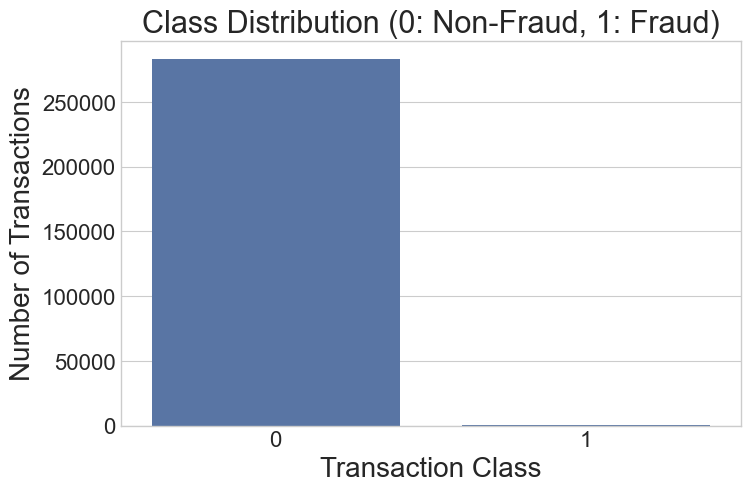

In [11]:
# Visualization
sns.countplot(x="Class", data=base)
plt.title("Class Distribution (0: Non-Fraud, 1: Fraud)")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

The dataset is highly imbalanced.

Fraud transactions represent less than 0.2% of the data. This imbalanced must be handled during model training using techniques such as SMMOTE or undersampling.

## Transaction Amount Distribution

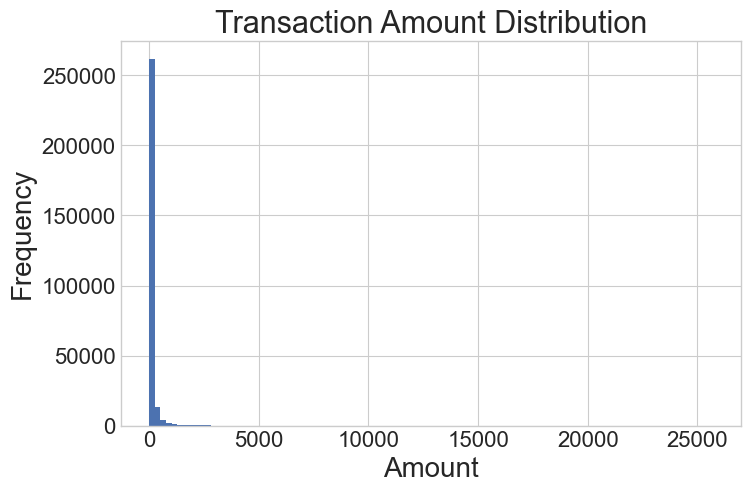

In [12]:
# Transaction Amount Distribution

plt.hist(base["Amount"], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

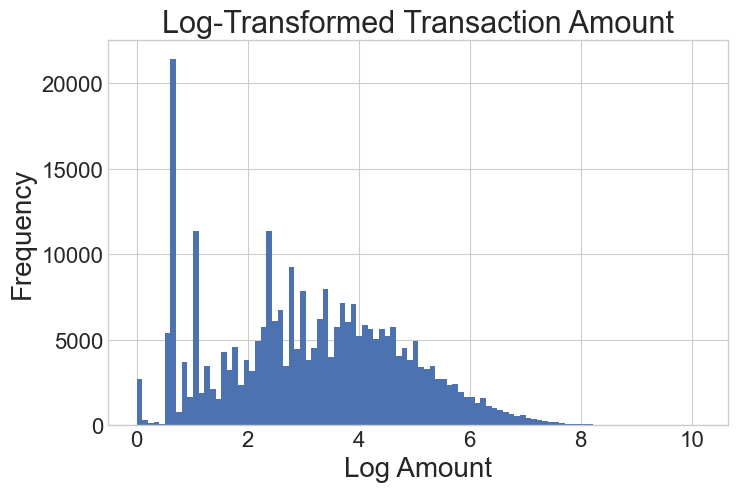

In [13]:
# Better version

# Make a copy version
df = base.copy()
# Create LogAmount variable
# Log transformation reduces skewness of the Amount distribution
df["LogAmount"] = np.log1p(df["Amount"])

plt.hist(df["LogAmount"], bins=100)
plt.title("Log-Transformed Transaction Amount")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

## Correlation Analysis

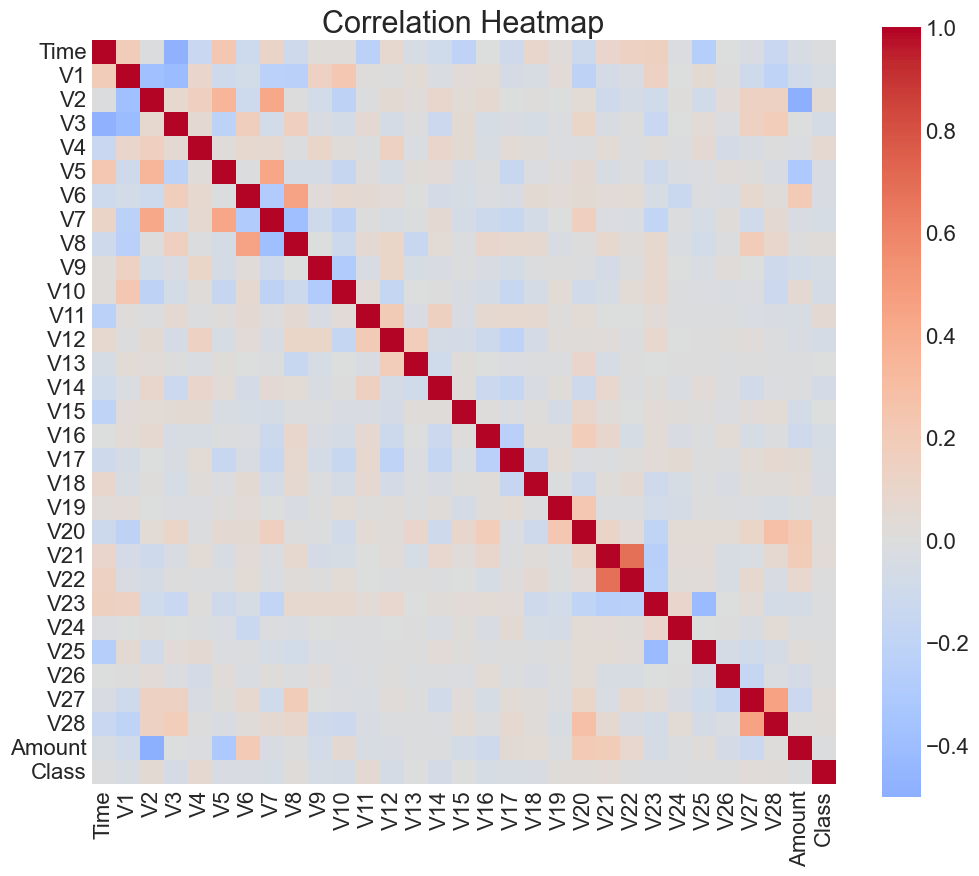

In [14]:
corr = base.corr(method="spearman")
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Features most correlated wiht fraud
fraud_corr = corr["Class"].sort_values(ascending=False)
fraud_corr.head(10)

Class    1.000000
V4       0.061652
V11      0.058624
V2       0.049435
V21      0.034375
V27      0.028511
V8       0.022945
V20      0.022145
V19      0.022107
V28      0.020683
Name: Class, dtype: float64

V4, V11, and V2 have the highest positive correlation with fraud (Class = 1), but the correlation coefficients are quite small. This shows that linear correlation alone is insufficient, and detecting fraud effectively requires models that capture subtle, non-linear patterns.

## Save clean dataset

In [16]:
# save clean dataset
base.to_csv("../data/processed/creditcard.csv", index=False)

# Conclusion

- Dataset is extremely imbalanced (fraud < 0.2%)
- No missing values
- 1081 duplicated rows removed
- Transaction amounts are highly skewed
- Several PCA components (V4, V11 and V2) correlate with fraud